In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA

In [2]:
soy_raw = pd.read_csv('soy_raw.csv')
sm = pd.read_csv('sm.csv')
vod = pd.read_csv('vod.csv')

In [3]:
# Process the daily soil moisture and VOD data into a 4-month mean, 90th percentile, 10th percentile and standard deviation.

sm_data = pd.DataFrame({
    'sm_mean': sm.mean(axis=1),
    'sm_q5': sm.quantile(0.05, axis=1),
    'sm_q95': sm.quantile(0.95, axis=1),
    'sm_std': sm.std(axis=1)
})

vod_data = pd.DataFrame({
    'vod_mean': vod.mean(axis=1),
    'vod_q5': vod.quantile(0.05,axis=1),
    'vod_q95': vod.quantile(0.95,axis=1),
    'vod_std': vod.std(axis=1)
})

sm_data.head()

,sm_mean,sm_q5,sm_q95,sm_std
0,0.160216,0.091869,0.238131,0.044583
1,0.197299,0.138234,0.236725,0.032614
2,0.172573,0.073943,0.233433,0.045325
3,0.220197,0.152329,0.265495,0.035747
4,0.179592,0.063475,0.265588,0.055550


In [4]:
# Combine all values into one final dataframe

soy_data = pd.concat([soy_raw, sm_data, vod_data],axis=1)
soy_data.head()

,yield,tmax_apr,tmax_may,tmax_jun,tmax_jul,prcp_apr,prcp_may,prcp_jun,prcp_jul,year,sm_mean,sm_q5,sm_q95,sm_std,vod_mean,vod_q5,vod_q95,vod_std
0,4.194062,26.944885,31.191715,33.047821,34.505318,197.227264,133.386368,137.943176,186.301132,2015,0.160216,0.091869,0.238131,0.044583,0.393141,0.316100,0.494518,0.054919
1,7.157392,19.691486,23.379566,27.378342,28.906879,64.965958,128.230209,273.581238,253.794022,2015,0.197299,0.138234,0.236725,0.032614,0.279009,0.225902,0.321308,0.032779
2,9.170855,16.248007,21.388821,25.129047,27.099064,81.545547,136.449112,167.224213,122.737778,2015,0.172573,0.073943,0.233433,0.045325,0.227040,0.167861,0.288062,0.038181
3,7.172860,19.613501,23.488871,27.322500,28.711775,59.570000,123.529999,280.100006,241.889999,2015,0.220197,0.152329,0.265495,0.035747,0.317403,0.262077,0.391281,0.038965
4,9.197968,17.863222,22.617496,26.069649,27.146734,89.199593,138.738678,218.345963,111.989548,2015,0.179592,0.063475,0.265588,0.055550,0.206323,0.136790,0.282111,0.047684


<Axes: >

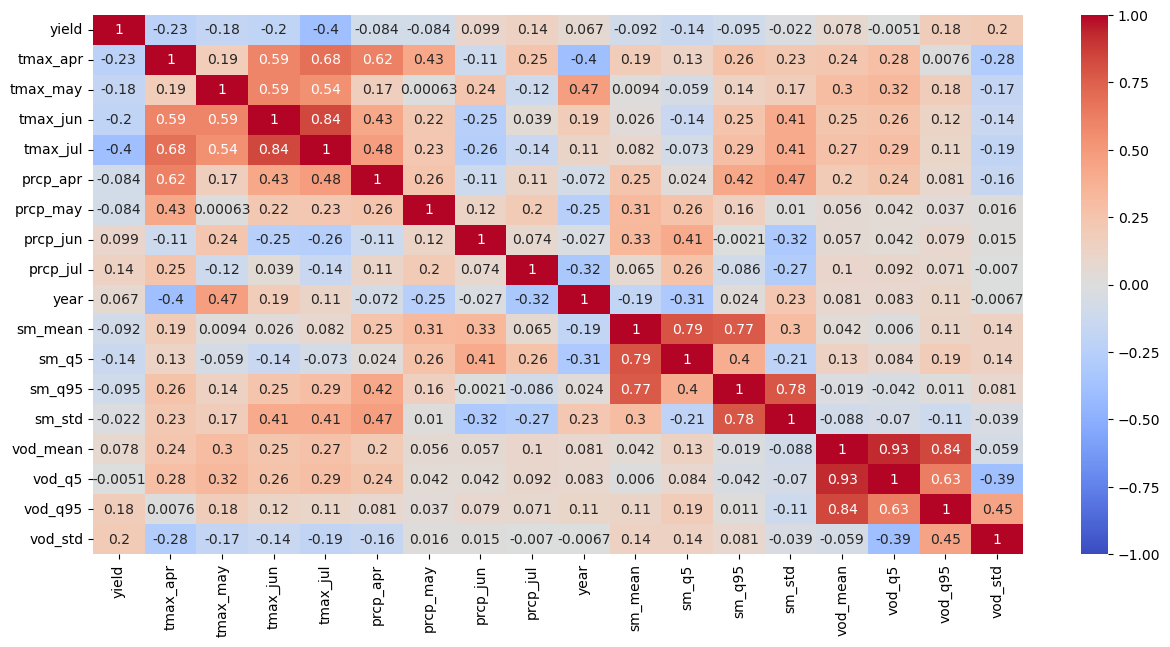

In [5]:
# Create a correlation matrix to determine features.

fig,axes = plt.subplots(1,1,figsize=(15,7))
soy_corr_mat = soy_data.corr(numeric_only=True)
sb.heatmap(soy_corr_mat, annot=True, vmin=-1, vmax=1, cmap='coolwarm', ax=axes)

,yield,tmax_apr,tmax_may,tmax_jun,tmax_jul,prcp_apr,prcp_may,prcp_jun,prcp_jul,sm_mean,sm_q5,sm_q95,vod_std,year
0,4.194062,26.944885,31.191715,33.047821,34.505318,197.227264,133.386368,137.943176,186.301132,0.160216,0.091869,0.238131,0.054919,2015
1,7.157392,19.691486,23.379566,27.378342,28.906879,64.965958,128.230209,273.581238,253.794022,0.197299,0.138234,0.236725,0.032779,2015
2,9.170855,16.248007,21.388821,25.129047,27.099064,81.545547,136.449112,167.224213,122.737778,0.172573,0.073943,0.233433,0.038181,2015
3,7.172860,19.613501,23.488871,27.322500,28.711775,59.570000,123.529999,280.100006,241.889999,0.220197,0.152329,0.265495,0.038965,2015
4,9.197968,17.863222,22.617496,26.069649,27.146734,89.199593,138.738678,218.345963,111.989548,0.179592,0.063475,0.265588,0.047684,2015


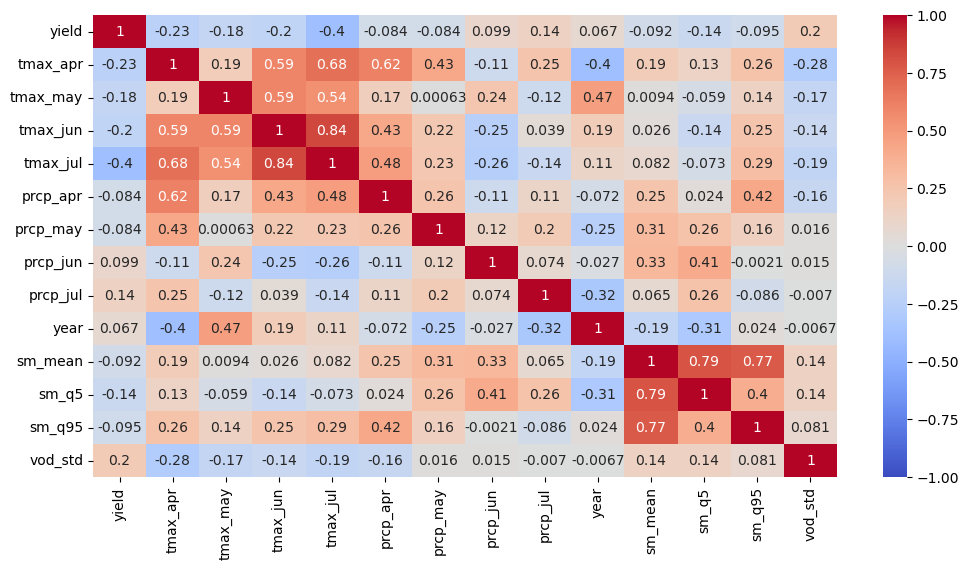

In [6]:
# Create a second correlation matrix with only the features and the label for legibility.


fig,axes2 = plt.subplots(1,1,figsize=(12,6))
soy_new = soy_data.drop(columns=["sm_std","vod_mean","vod_q5","vod_q95"])
soy_corr_mat_3 = soy_new.corr(numeric_only=True)
sb.heatmap(soy_corr_mat_3, annot=True, vmin=-1, vmax=1, cmap='coolwarm', ax=axes2)

years = soy_new.pop("year")
soy_new.insert(13, 'year', years)
soy_new.head()


In [7]:
# Create training sets and testing sets

features = soy_new.columns.drop(['yield','year'])

X_train = soy_new.loc[soy_new['year']<2018, features].to_numpy()
y_train = soy_new.loc[soy_new['year']<2018, 'yield'].to_numpy()

X_test = soy_new.loc[soy_new['year']==2018, features].to_numpy()
y_test = soy_new.loc[soy_new['year']==2018, 'yield'].to_numpy()



In [8]:
# Normalise features

scaler = StandardScaler()

scaler.fit(X_train)
X_train_norm = scaler.transform(X_train)
X_test_norm = scaler.transform(X_test)

In [9]:
# Train the Ridge parameter

alphas = np.logspace(-2, 5, 20)
print(alphas)

model = RidgeCV(alphas = alphas, cv = 3, scoring = 'neg_root_mean_squared_error')

model.fit(X_train_norm,y_train)

y_pred = model.predict(X_test_norm)
print(root_mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

print(model.get_params())

print("best alpha:", model.alpha_)
print("CV RMSE at best alpha:", -model.best_score_)


[1.00000000e-02 2.33572147e-02 5.45559478e-02 1.27427499e-01
 2.97635144e-01 6.95192796e-01 1.62377674e+00 3.79269019e+00
 8.85866790e+00 2.06913808e+01 4.83293024e+01 1.12883789e+02
 2.63665090e+02 6.15848211e+02 1.43844989e+03 3.35981829e+03
 7.84759970e+03 1.83298071e+04 4.28133240e+04 1.00000000e+05]
2.128427306019577
0.08609273579060295
{'alpha_per_target': False, 'alphas': array([1.00000000e-02, 2.33572147e-02, 5.45559478e-02, 1.27427499e-01,
       2.97635144e-01, 6.95192796e-01, 1.62377674e+00, 3.79269019e+00,
       8.85866790e+00, 2.06913808e+01, 4.83293024e+01, 1.12883789e+02,
       2.63665090e+02, 6.15848211e+02, 1.43844989e+03, 3.35981829e+03,
       7.84759970e+03, 1.83298071e+04, 4.28133240e+04, 1.00000000e+05]), 'cv': 3, 'fit_intercept': True, 'gcv_mode': None, 'scoring': 'neg_root_mean_squared_error', 'store_cv_results': False}
best alpha: 263.6650898730355
CV RMSE at best alpha: 1.9960317417188864


In [10]:
#PASKA

degrees = [1,2,3,4]
tr_e = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_norm)
    X_test_poly = poly.transform(X_test_norm)
    modelX = LinearRegression()
    modelX.fit(X_train_poly,y_train)
    y_tr_pr = modelX.predict(X_train_poly)
    tr_er = root_mean_squared_error(y_train,y_tr_pr)
    y_v_pr = modelX.predict(X_test_poly)
    v_er = root_mean_squared_error(y_test,y_v_pr)
    print("")
    print("training = ",tr_er," validation = ",v_er)
    print("R2training = ", r2_score(y_train,y_tr_pr), ", R2testing = ", r2_score(y_test,y_v_pr))


training =  1.794756014904853  validation =  2.2301598376528013
R2training =  0.3111955569287951 , R2testing =  -0.0033592674985862825

training =  1.2864920984341757  validation =  7.421456953246077
R2training =  0.6460846892109839 , R2testing =  -10.111247742266515

training =  0.9050769303039122  validation =  24.674779967175418
R2training =  0.8248314660271105 , R2testing =  -121.8262132508019

training =  6.193170358811192e-13  validation =  265.0484207424907
R2training =  1.0 , R2testing =  -14171.123466613992


In [11]:
#ദ്ദി◝ ⩊ ◜.ᐟ

degrees = [1,2,3,4]
tr_e = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_norm)
    X_test_poly = poly.transform(X_test_norm)
    modelY = RidgeCV(alphas = alphas, cv = 3, scoring = 'neg_root_mean_squared_error')
    modelY.fit(X_train_poly,y_train)
    y_tr_pr = modelY.predict(X_train_poly)
    tr_er = root_mean_squared_error(y_train,y_tr_pr)
    y_v_pr = modelY.predict(X_test_poly)
    v_er = root_mean_squared_error(y_test,y_v_pr)
    print("")
    print("training = ",tr_er," validation = ",v_er)
    print("R2training = ", r2_score(y_train,y_tr_pr), ", R2testing = ", r2_score(y_test,y_v_pr))
    
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_norm)
X_test_poly = poly.transform(X_test_norm)
modelY2 = RidgeCV(alphas = alphas, cv = 3, scoring = 'neg_root_mean_squared_error')
modelY2.fit(X_train_poly,y_train)

print(modelY2.get_params())

print("best alpha:", modelY2.alpha_)
print("CV RMSE at best alpha:", -modelY2.best_score_)


training =  1.8341131187984079  validation =  2.128427306019577
R2training =  0.2806548177016328 , R2testing =  0.08609273579060295

training =  1.401299504046786  validation =  2.039078352823827
R2training =  0.5800988718615709 , R2testing =  0.16121179710891675

training =  1.7026151253241957  validation =  2.060991074356582
R2training =  0.380105077391776 , R2testing =  0.14308704748297363

training =  1.7132429384362426  validation =  2.1454679105456043
R2training =  0.3723420909046705 , R2testing =  0.07140031515831302
{'alpha_per_target': False, 'alphas': array([1.00000000e-02, 2.33572147e-02, 5.45559478e-02, 1.27427499e-01,
       2.97635144e-01, 6.95192796e-01, 1.62377674e+00, 3.79269019e+00,
       8.85866790e+00, 2.06913808e+01, 4.83293024e+01, 1.12883789e+02,
       2.63665090e+02, 6.15848211e+02, 1.43844989e+03, 3.35981829e+03,
       7.84759970e+03, 1.83298071e+04, 4.28133240e+04, 1.00000000e+05]), 'cv': 3, 'fit_intercept': True, 'gcv_mode': None, 'scoring': 'neg_root_mea

In [12]:
#ദ്ദി◝ ⩊ ◜)

components = [0.94,0.95, 0.96, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

for component in components:
    pca = PCA(n_components=component)
    X_train_pca = pca.fit_transform(X_train_norm)
    X_test_pca = pca.transform(X_test_norm)
    model2 = LinearRegression()
    model2.fit(X_train_pca,y_train)

    y_train_pred = model2.predict(X_train_pca)
    tr_error = root_mean_squared_error(y_train,y_train_pred)

    y_test_pred = model2.predict(X_test_pca)
    v_error = root_mean_squared_error(y_test,y_test_pred)

    print(" ")
    print(component)
    print(tr_error,v_error)
    print("training = ", r2_score(y_train,y_train_pred), ", testing = ", r2_score(y_test,y_test_pred))

 
0.94
1.8691474113389506 2.050795065624028
training =  0.25291122351307194 , testing =  0.15154460972323258
 
0.95
1.8691474113389506 2.050795065624028
training =  0.25291122351307194 , testing =  0.15154460972323258
 
0.96
1.8691474113389506 2.050795065624028
training =  0.25291122351307194 , testing =  0.15154460972323258
 
2
2.0640005456005506 2.146790660649736
training =  0.08902864640850361 , testing =  0.07025493892715118
 
3
2.0629623092204312 2.141752741639947
training =  0.08994489201982347 , testing =  0.07461352349284267
 
4
2.037718457136927 2.156803003065511
training =  0.11208076697608582 , testing =  0.061562304037295235
 
5
1.986897355878174 2.3434510752653863
training =  0.1558182317557576 , testing =  -0.10788904405585042
 
6
1.9255899285695812 2.2758235551836323
training =  0.20711040917534096 , testing =  -0.044868560574008454
 
7
1.8978960840983 2.2520505100565704
training =  0.2297530907704466 , testing =  -0.023153370283646835
 
8
1.8691474113389506 2.0507950656

In [13]:
#HUONO

components = [0.94,0.95, 0.96, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

for component in components:
    pca = PCA(n_components=component)
    X_train_pca = pca.fit_transform(X_train_norm)
    X_test_pca = pca.transform(X_test_norm)
    model3 = RidgeCV(alphas = alphas, cv = 3, scoring = 'neg_root_mean_squared_error')
    model3.fit(X_train_pca,y_train)

    y_train_pred = model3.predict(X_train_pca)
    tr_error = root_mean_squared_error(y_train,y_train_pred)

    y_test_pred = model3.predict(X_test_pca)
    v_error = root_mean_squared_error(y_test,y_test_pred)

    print(" ")
    print(component)
    print(tr_error,v_error)
    print("training = ", r2_score(y_train,y_train_pred), ", testing = ", r2_score(y_test,y_test_pred))

 
0.94
1.8801970871470761 2.0690067882348075
training =  0.2440521156929033 , testing =  0.13640858456404792
 
0.95
1.8801970871470761 2.0690067882348075
training =  0.2440521156929033 , testing =  0.13640858456404792
 
0.96
1.8801970871470761 2.0690067882348075
training =  0.2440521156929033 , testing =  0.13640858456404792
 
2
2.0674348309122665 2.1489409638982724
training =  0.08599459845060842 , testing =  0.06839147350940944
 
3
2.066550770844399 2.1458059145646557
training =  0.08677611078884073 , testing =  0.07110770285858181
 
4
2.046514230334049 2.14689054930866
training =  0.10439885009047356 , testing =  0.07016841614725933
 
5
1.989368842806603 2.2888065818420706
training =  0.15371678266157085 , testing =  -0.05682401332924436
 
6
1.9267711999480746 2.2526023914983884
training =  0.20613729952767457 , testing =  -0.02365489415411348
 
7
1.9047236125463567 2.1995162407439444
training =  0.22420132012021476 , testing =  0.024024688975297748
 
8
1.8801970871470761 2.06900678